In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("WineQT.csv")

In [3]:
print (df.head())
print(df.shape)
print(df.columns.tolist)
print(df.info())
print(df.describe())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [4]:
print(df.isnull())

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0             False             False        False           False      False   
1             False             False        False           False      False   
2             False             False        False           False      False   
3             False             False        False           False      False   
4             False             False        False           False      False   
...             ...               ...          ...             ...        ...   
1138          False             False        False           False      False   
1139          False             False        False           False      False   
1140          False             False        False           False      False   
1141          False             False        False           False      False   
1142          False             False        False           False      False   

      free sulfur dioxide  

In [5]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [6]:
##Correlation matrix

In [7]:
corr_matrix = df.corr()
print(corr_matrix)


                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970         -0.407394     0.240821   
Id                        -0.275826         -0.007892    -0.139011   

                   


Correlation with Quality:
quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


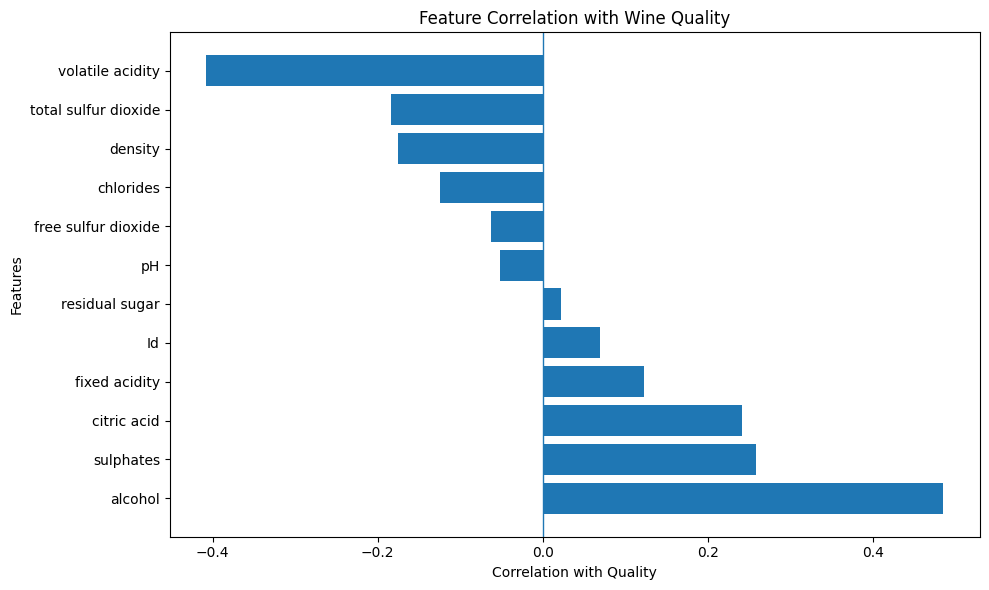

In [8]:
target = "quality"

quality_corr = corr_matrix[target].sort_values(
    ascending=False
)

print("\nCorrelation with Quality:")
print(quality_corr)
feature_corr = quality_corr.drop(target)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_corr.index,
    feature_corr.values
)

plt.xlabel("Correlation with Quality")
plt.ylabel("Features")
plt.title("Feature Correlation with Wine Quality")

plt.axvline(
    x=0,
    linewidth=1
)

plt.tight_layout()
plt.show()



In [9]:
##Dropping residual sugar as its correlation with quality is very less
df = df.drop(["residual sugar","Id"], axis=1)


In [10]:
df

,fixed acidity,volatile acidity,citric acid,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1139,6.8,0.620,0.08,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1140,6.2,0.600,0.08,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1141,5.9,0.550,0.10,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6


In [11]:
df["quality_binary"] = (df["quality"] >= 6).astype(int)

print(df[["quality", "quality_binary"]].head(20))
print("\nClass distribution:")
print(df["quality_binary"].value_counts())

print("\nClass percentage:")
print(df["quality_binary"].value_counts(normalize=True) * 100)

    quality  quality_binary
0         5               0
1         5               0
2         5               0
3         6               1
4         5               0
5         5               0
6         5               0
7         7               1
8         7               1
9         5               0
10        5               0
11        5               0
12        7               1
13        6               1
14        5               0
15        5               0
16        5               0
17        6               1
18        5               0
19        5               0

Class distribution:
quality_binary
1    621
0    522
Name: count, dtype: int64

Class percentage:
quality_binary
1    54.330709
0    45.669291
Name: proportion, dtype: float64


In [12]:
X = df.drop(
    ["quality", "quality_binary"],
    axis=1
)

# Target
y = df["quality_binary"]

# Convert to NumPy
X = X.values
y = y.values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1143, 10)
y shape: (1143,)


In [13]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (914, 10)
X_test : (229, 10)
y_train: (914,)
y_test : (229,)


In [14]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

In [18]:
print("Training means:")
print(np.mean(X_train_norm, axis=0))

print("\nTraining standard deviations:")
print(np.std(X_train_norm, axis=0))

Training means:
[ 1.82178610e-15  5.98111398e-16 -4.96806583e-16  3.27540086e-15
 -6.17060499e-17  9.45025726e-17  3.89412366e-13  3.71574884e-14
  4.31966643e-15  1.33733894e-14]

Training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [19]:
# ============================================================
# LOGISTIC REGRESSION FROM SCRATCH
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. SIGMOID FUNCTION
# ------------------------------------------------------------

def sigmoid(z):
    
    return 1 / (1 + np.exp(-z))


# ------------------------------------------------------------
# 2. LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

def compute_model_output(X, w, b):
    
    z = np.dot(X, w) + b
    
    probabilities = sigmoid(z)
    
    return probabilities


# ------------------------------------------------------------
# 3. INITIALIZE PARAMETERS
# ------------------------------------------------------------

w_init = np.zeros(X_train_norm.shape[1])
b_init = 0

print("Initial weights:")
print(w_init)

print("\nInitial bias:")
print(b_init)


# ------------------------------------------------------------
# 4. INITIAL PREDICTIONS
# ------------------------------------------------------------

initial_probabilities = compute_model_output(
    X_train_norm,
    w_init,
    b_init
)

print("\nInitial probabilities:")
print(initial_probabilities[:10])


# ------------------------------------------------------------
# 5. LOGISTIC COST FUNCTION
# ------------------------------------------------------------

def compute_cost(X, y, w, b):
    
    m = X.shape[0]
    
    probabilities = compute_model_output(
        X,
        w,
        b
    )
    
    # Prevent log(0)
    epsilon = 1e-15
    
    probabilities = np.clip(
        probabilities,
        epsilon,
        1 - epsilon
    )
    
    cost = -(1 / m) * np.sum(
        y * np.log(probabilities)
        +
        (1 - y) * np.log(1 - probabilities)
    )
    
    return cost


def compute_cost_reg(X, y, w, b, lambda_):

    m = X.shape[0]

    probabilities = compute_model_output(
        X,
        w,
        b
    )

    epsilon = 1e-15

    probabilities = np.clip(
        probabilities,
        epsilon,
        1 - epsilon
    )

    # Original logistic cost
    logistic_cost = -(1 / m) * np.sum(
        y * np.log(probabilities)
        +
        (1 - y) * np.log(1 - probabilities)
    )

    # L2 regularization
    regularization_cost = (
        lambda_ / (2 * m)
    ) * np.sum(w ** 2)

    total_cost = (
        logistic_cost
        + regularization_cost
    )

    return total_cost
# Check initial cost

initial_cost = compute_cost(
    X_train_norm,
    y_train,
    w_init,
    b_init
)

print("\nInitial cost:", initial_cost)


# ------------------------------------------------------------
# 6. COMPUTE GRADIENT
# ------------------------------------------------------------

def compute_gradient(X, y, w, b):
    
    m = X.shape[0]
    
    probabilities = compute_model_output(
        X,
        w,
        b
    )
    
    errors = probabilities - y
    
    # Gradient with respect to weights
    dj_dw = (1 / m) * np.dot(
        X.T,
        errors
    )
    
    # Gradient with respect to bias
    dj_db = (1 / m) * np.sum(errors)
    
    return dj_dw, dj_db


# Check gradient

dj_dw, dj_db = compute_gradient(
    X_train_norm,
    y_train,
    w_init,
    b_init
)

print("\ndj_dw:")
print(dj_dw)

print("\ndj_db:")
print(dj_db)
# ============================================================
# REGULARIZED GRADIENT
# ============================================================

def compute_gradient_reg(
    X,
    y,
    w,
    b,
    lambda_
):

    m = X.shape[0]

    probabilities = compute_model_output(
        X,
        w,
        b
    )

    errors = probabilities - y

    # Original gradient
    dj_dw = (1 / m) * np.dot(
        X.T,
        errors
    )

    dj_db = (1 / m) * np.sum(errors)

    # L2 regularization
    dj_dw = dj_dw + (lambda_ / m) * w

    # Bias is NOT regularized

    return dj_dw, dj_db

# ------------------------------------------------------------
# 7. GRADIENT DESCENT
# ------------------------------------------------------------

def gradient_descent(
    X,
    y,
    w,
    b,
    alpha,
    num_iters
):
    
    J_history = []
    
    for i in range(num_iters):
        
        # Calculate gradient
        dj_dw, dj_db = compute_gradient(
            X,
            y,
            w,
            b
        )
        
        # Update weights
        w = w - alpha * dj_dw
        
        # Update bias
        b = b - alpha * dj_db
        
        # Calculate cost
        cost = compute_cost(
            X,
            y,
            w,
            b
        )
        
        J_history.append(cost)
    
    return w, b, J_history

# ============================================================
# REGULARIZED GRADIENT DESCENT
# ============================================================

def gradient_descent_reg(
    X,
    y,
    w,
    b,
    alpha,
    num_iters,
    lambda_
):

    J_history = []

    for i in range(num_iters):

        # Regularized gradient
        dj_dw, dj_db = compute_gradient_reg(
            X,
            y,
            w,
            b,
            lambda_
        )

        # Update weights
        w = w - alpha * dj_dw

        # Update bias
        b = b - alpha * dj_db

        # Regularized cost
        cost = compute_cost_reg(
            X,
            y,
            w,
            b,
            lambda_
        )

        J_history.append(cost)

    return w, b, J_history

Initial weights:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Initial bias:
0

Initial probabilities:
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]

Initial cost: 0.6931471805599452

dj_dw:
[-0.04283557  0.15529394 -0.06939769  0.05115976  0.02663605  0.10683019
  0.07640551 -0.01016319 -0.11704067 -0.22029025]

dj_db:
-0.037199124726477024


In [35]:
# ============================================================
# TRAINING
# ============================================================

w_init = np.zeros(X_train_norm.shape[1])
b_init = 0

alpha = 0.005
num_iters =5000

w_final, b_final, J_history = gradient_descent(
    X_train_norm,
    y_train,
    w_init,
    b_init,
    alpha,
    num_iters
)

print("Training complete!")

print("\nFinal weights:")
print(w_final)

print("\nFinal bias:")
print(b_final)

# ============================================================
# TRAIN REGULARIZED MODEL
# ============================================================

w_init = np.zeros(
    X_train_norm.shape[1]
)

b_init = 0

alpha = 0.005
num_iters = 5000

lambda_ = 0

w_reg, b_reg, J_history_reg = gradient_descent_reg(
    X_train_norm,
    y_train,
    w_init,
    b_init,
    alpha,
    num_iters,
    lambda_
)

print("Training complete!")

print("\nLambda:", lambda_)

print("\nFinal weights:")
print(w_reg)

print("\nFinal bias:")
print(b_reg)

Training complete!

Final weights:
[ 0.26803664 -0.49203014 -0.14427099 -0.18647217  0.14774706 -0.42825871
 -0.13620108  0.02211964  0.48931679  0.90718175]

Final bias:
0.2539699284686022
Training complete!

Lambda: 0

Final weights:
[ 0.26803664 -0.49203014 -0.14427099 -0.18647217  0.14774706 -0.42825871
 -0.13620108  0.02211964  0.48931679  0.90718175]

Final bias:
0.2539699284686022


In [45]:
# ============================================================
# EVALUATION
# ============================================================

# 1. Predict probabilities
y_train_prob = compute_model_output(
    X_train_norm,
    w_final,
    b_final
)

y_test_prob = compute_model_output(
    X_test_norm,
    w_final,
    b_final
)


# 2. Convert probabilities to classes
threshold = 0.5
y_train_pred = (
    y_train_prob >= threshold
).astype(int)

y_test_pred = (
    y_test_prob >= threshold
).astype(int)


# 3. Accuracy
train_accuracy = np.mean(
    y_train_pred == y_train
)

test_accuracy = np.mean(
    y_test_pred == y_test
)


print("Threshold:", threshold)

print(
    "Train Accuracy:",
    train_accuracy * 100,
    "%"
)

print(
    "Test Accuracy:",
    test_accuracy * 100,
    "%"
)

Threshold: 0.45
Train Accuracy: 75.92997811816193 %
Test Accuracy: 76.85589519650655 %


In [46]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

TP = np.sum(
    (y_test == 1) & (y_test_pred == 1)
)

TN = np.sum(
    (y_test == 0) & (y_test_pred == 0)
)

FP = np.sum(
    (y_test == 0) & (y_test_pred == 1)
)

FN = np.sum(
    (y_test == 1) & (y_test_pred == 0)
)


print("\nConfusion Matrix:")
print("True Positives :", TP)
print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)


Confusion Matrix:
True Positives : 103
True Negatives : 73
False Positives: 26
False Negatives: 27


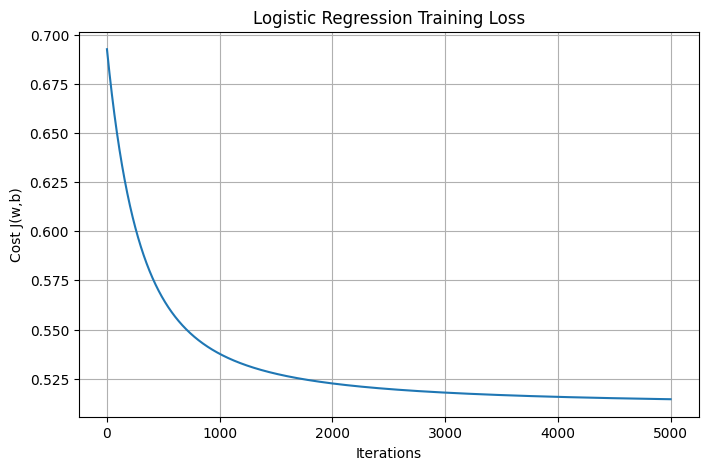

In [47]:
# ============================================================
# TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(J_history)

plt.xlabel("Iterations")
plt.ylabel("Cost J(w,b)")

plt.title("Logistic Regression Training Loss")

plt.grid(True)

plt.show()

In [48]:
# ============================================================
# PRECISION, RECALL AND F1 SCORE
# ============================================================

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1_score = (
    2 * precision * recall
) / (precision + recall)


print("\nPrecision:", precision * 100, "%")
print("Recall   :", recall * 100, "%")
print("F1 Score :", f1_score * 100, "%")



Precision: 79.84496124031007 %
Recall   : 79.23076923076923 %
F1 Score : 79.53667953667953 %


In [49]:
# ============================================================
# PREDICTIONS AND ACCURACY
# ============================================================

# ------------------------------------------------------------
# 1. PREDICT PROBABILITIES
# ------------------------------------------------------------

y_train_prob = compute_model_output(
    X_train_norm,
    w_final,
    b_final
)

y_test_prob = compute_model_output(
    X_test_norm,
    w_final,
    b_final
)


# ------------------------------------------------------------
# 2. CONVERT PROBABILITIES TO CLASS LABELS
# ------------------------------------------------------------

threshold = 0.45

y_train_pred = (
    y_train_prob >= threshold
).astype(int)

y_test_pred = (
    y_test_prob >= threshold
).astype(int)


# ------------------------------------------------------------
# 3. ACCURACY FUNCTION
# ------------------------------------------------------------

def compute_accuracy(y_actual, y_pred):
    
    return np.mean(y_actual == y_pred)


# ------------------------------------------------------------
# 4. CALCULATE ACCURACY
# ------------------------------------------------------------

train_accuracy = compute_accuracy(
    y_train,
    y_train_pred
)

test_accuracy = compute_accuracy(
    y_test,
    y_test_pred
)


# ------------------------------------------------------------
# 5. DISPLAY RESULTS
# ------------------------------------------------------------

print("Classification Threshold:", threshold)

print(
    "\nTrain Accuracy:",
    train_accuracy * 100,
    "%"
)

print(
    "Test Accuracy:",
    test_accuracy * 100,
    "%"
)

# ============================================================
# REGULARIZED MODEL ACCURACY
# ============================================================

y_train_prob_reg = compute_model_output(
    X_train_norm,
    w_reg,
    b_reg
)

y_test_prob_reg = compute_model_output(
    X_test_norm,
    w_reg,
    b_reg
)

threshold = 0.45

y_train_pred_reg = (
    y_train_prob_reg >= threshold
).astype(int)

y_test_pred_reg = (
    y_test_prob_reg >= threshold
).astype(int)

train_accuracy_reg = np.mean(
    y_train_pred_reg == y_train
)

test_accuracy_reg = np.mean(
    y_test_pred_reg == y_test
)

print(
    "Train Accuracy:",
    train_accuracy_reg * 100,
    "%"
)

print(
    "Test Accuracy:",
    test_accuracy_reg * 100,
    "%"
)

Classification Threshold: 0.45

Train Accuracy: 75.92997811816193 %
Test Accuracy: 76.85589519650655 %
Train Accuracy: 75.92997811816193 %
Test Accuracy: 76.85589519650655 %


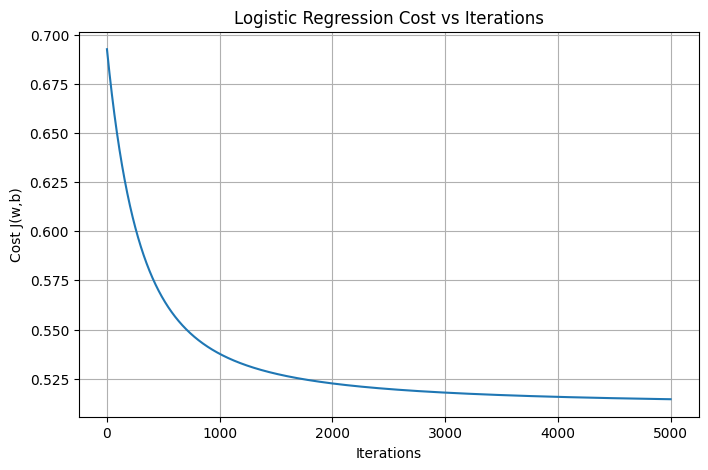

In [50]:
# ============================================================
# CHECK CONVERGENCE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(J_history)

plt.xlabel("Iterations")
plt.ylabel("Cost J(w,b)")

plt.title("Logistic Regression Cost vs Iterations")

plt.grid(True)

plt.show()